# Evaluation (Polars)

## R2
The Coefficient of Determination, R2, is a measure of how well the model fits the data. 
It is a value between 0 and 1. It tells us how much of the variance in the target variable 
is predictable from the features. 
    
A value of 0 means that the model explains none of the variability. 
A value of 1 means that the model explains all the variability. 
    
Note that it doesn't indicate whether a model is overfitting or underfitting the data.

In [1]:
from sklearn.model_selection import train_test_split
# Custom import
from get_dataset_polars import get_polars_df
from pipes_and_transformers_polars import get_pipeline_polars

# Gets Polars dataframe.
raw = get_polars_df()

y = raw.select("price")
X_train, X_test, y_train, y_test = train_test_split(raw, y, test_size=0.2, random_state=42)

In [2]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor()
cat_pipe = get_pipeline_polars(cat)
cat_pipe.fit(X_train, y_train.to_numpy()[:,0])

print(cat_pipe.score(X_test, y_test.to_numpy()[:,0]))

Learning rate set to 0.064232
0:	learn: 346982.2594620	total: 145ms	remaining: 2m 24s
1:	learn: 332378.5598059	total: 149ms	remaining: 1m 14s
2:	learn: 319502.6617458	total: 152ms	remaining: 50.6s
3:	learn: 307490.7902475	total: 157ms	remaining: 39.1s
4:	learn: 294940.3225791	total: 161ms	remaining: 32.1s
5:	learn: 283907.9796375	total: 165ms	remaining: 27.4s
6:	learn: 273592.5548762	total: 169ms	remaining: 23.9s
7:	learn: 263472.9134855	total: 174ms	remaining: 21.5s
8:	learn: 254884.3331936	total: 178ms	remaining: 19.5s
9:	learn: 246261.9209853	total: 181ms	remaining: 18s
10:	learn: 238183.5765242	total: 186ms	remaining: 16.7s
11:	learn: 230600.1564374	total: 191ms	remaining: 15.7s
12:	learn: 223779.4367347	total: 194ms	remaining: 14.7s
13:	learn: 217021.8170437	total: 197ms	remaining: 13.9s
14:	learn: 210875.7711670	total: 201ms	remaining: 13.2s
15:	learn: 205122.1910805	total: 207ms	remaining: 12.7s
16:	learn: 199643.2642325	total: 213ms	remaining: 12.3s
17:	learn: 194468.6623792	to

In [3]:
cat_pipe.score(X_test, y_test.to_numpy()[:,0])

np.float64(0.9046473600451286)

## Mean Squared/ Absolute Error

In [4]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_test, cat_pipe.predict(X_test))

14415098613.389244

In [5]:
# rmse
# Unable to get this to work.
# mean_squared_error(y_test, cat_pipe.predict(X_test), squared=False)

# Alternative
import numpy as np

mse = mean_squared_error(y_test, cat_pipe.predict(X_test))
rmse = np.sqrt(mse)
print(rmse)

120062.89440701171


In [6]:
# absolute error
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_test, cat_pipe.predict(X_test))

64449.15608948771

## Compare lr model

In [7]:
from sklearn.linear_model import LinearRegression

lr =  LinearRegression()
lr_pipe = get_pipeline_polars(lr)
lr_pipe.fit(X_train, y_train)

from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_test, lr_pipe.predict(X_test))

98969.57211943854

## Residual Plot

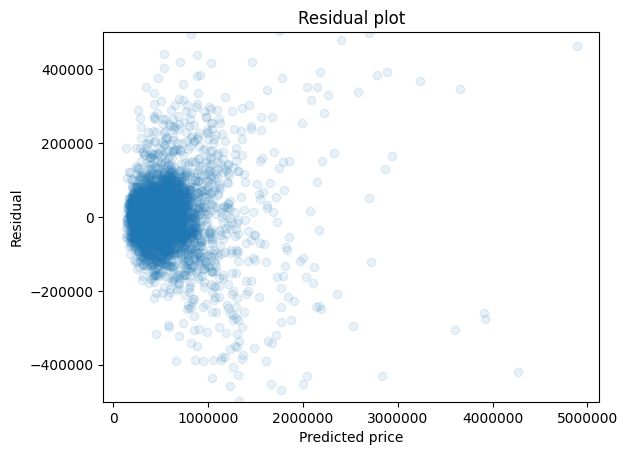

In [8]:
# make a residual plot
import matplotlib.pyplot as plt

ax = plt.scatter(cat_pipe.predict(X_test), 
    y_test.to_series().to_numpy() - cat_pipe.predict(X_test), alpha=0.1)
# make labels not be scientific notation
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.ylim(-500_000, 500_000)
plt.xlabel('Predicted price')
plt.ylabel('Residual')
plt.title('Residual plot')
plt.show()

In [9]:
# plot with Polars
(y_test
 .with_columns(predicted_price=cat_pipe.predict(X_test),
   residual=y_test.to_series().to_numpy() - cat_pipe.predict(X_test))
 .plot.scatter('predicted_price', 'residual') 
 ) 
# unable to get graph to plot with alpha, yformatter & xformatter arguments

alt.Chart(...)

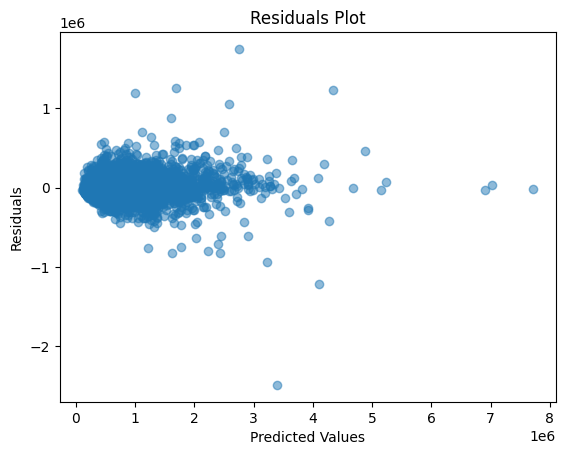

In [11]:
# Function to plot residual plot
def residuals_plot(model, X_train, y_train, X_test, y_test):
    df = (
        y_test.with_columns(
            prediction=model.predict(X_test),
            residual=y_test.to_series().to_numpy() - model.predict(X_test),
            type=pl.lit('test')
        )
        .vstack(
            y_train.with_columns(
                prediction=model.predict(X_train),
                residual=y_train.to_series().to_numpy() - model.predict(X_train),
                type=pl.lit('train')
            )
        )
        .reverse()
    )

    # Use matplotlib directly for plotting
    plt.scatter(df['prediction'], df['residual'], alpha=0.5)
##    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residuals Plot")
    plt.show()

residuals_plot(cat_pipe, X_train, y_train, X_test, y_test)

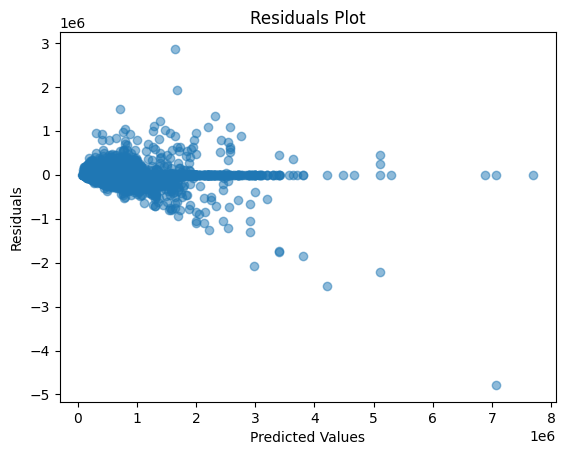

In [12]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt_pipe = get_pipeline_polars(dt)
dt_pipe.fit(X_train, y_train)

residuals_plot(dt_pipe, X_train, y_train, X_test, y_test)